# WC26 Data Exploration
SQL queries · data exploration · visualizations · saving new tables

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

con = duckdb.connect()

TABLES = {
    'matches':            'data/processed/wc26_matches.parquet',
    'players':            'data/processed/wc26_players.parquet',
    'nations':            'data/processed/wc26_nations.parquet',
    'stadiums':           'data/processed/wc26_stadiums.parquet',
    'player_stats':       'data/processed/wc26_player_match_stats.parquet',
    'powerrank':          'data/processed/wc26_player_match_powerrank.parquet',
    'season_stats':       'data/processed/wc26_player_season_stats.parquet',
    'enrichment':         'data/processed/wc26_player_enrichment.parquet',
    'market_value':       'data/processed/wc26_player_market_value_history.parquet',
    'fotmob_wc':          'data/processed/wc26_player_fotmob_wc.parquet',
    'weather':            'data/processed/wc26_match_weather.parquet',
    'referees':           'data/processed/referee_master.parquet',
    'referee_profile':    'data/processed/referee_profile.parquet',
    'referee_assign':     'data/processed/referee_assignments.parquet',
    'fantasy_players':    'data/processed/fantasy_players.parquet',
    'fantasy_squads':     'data/processed/fantasy_squads.parquet',
    'fantasy_rounds':     'data/processed/fantasy_rounds.parquet',
    'fantasy_stats':      'data/processed/fantasy_player_round_stats.parquet',
    'player_recent':      'data/processed/wc26_player_recent_matches_fotmob.parquet',
    'match_stats_wide':   'data/processed/wc26_player_match_stats_wide.parquet',
    'season_stats_wide':  'data/processed/wc26_player_season_stats_wide.parquet',
    'powerrank_wide':     'data/processed/wc26_player_match_powerrank.parquet',
    'polymarket_events':  'data/processed/wc26_match_polymarket_events.parquet',
    'polymarket_markets': 'data/processed/wc26_match_polymarket_markets.parquet',
}

for name, path in TABLES.items():
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM '{path}'")

print(f'✓ {len(TABLES)} tables registered')
print(list(TABLES.keys()))

✓ 24 tables registered
['matches', 'players', 'nations', 'stadiums', 'player_stats', 'powerrank', 'season_stats', 'enrichment', 'market_value', 'fotmob_wc', 'weather', 'referees', 'referee_profile', 'referee_assign', 'fantasy_players', 'fantasy_squads', 'fantasy_rounds', 'fantasy_stats', 'player_recent', 'match_stats_wide', 'season_stats_wide', 'powerrank_wide', 'polymarket_events', 'polymarket_markets']


---
## 1. Data Exploration — shape, columns, samples

In [6]:
# Quick schema overview of every table
for name in TABLES:
    df = con.execute(f'SELECT * FROM {name} LIMIT 0').df()
    row_count = con.execute(f'SELECT COUNT(*) FROM {name}').fetchone()[0]
    print(f'{name:25s}  rows={row_count:>6,}  cols={len(df.columns):>3}  {list(df.columns)[:6]}...')

matches                    rows=   104  cols= 30  ['match_number', 'espn_match_id', 'fifa_match_id', 'fifa_id_ifes', 'seed_match_id', 'kickoff_utc']...
players                    rows= 1,248  cols= 23  ['nation_id', 'fifa_team_id', 'fifa_player_id', 'name', 'short_name', 'jersey_num']...
nations                    rows=    48  cols= 21  ['nation_id', 'seed_name', 'iso_alpha2', 'confederation', 'group', 'pot']...
stadiums                   rows=    16  cols= 17  ['stadium_id', 'name', 'city', 'state_or_region', 'country', 'capacity']...
player_stats               rows=116,340  cols=  5  ['fifa_match_id', 'fifa_id_ifes', 'fifa_player_id', 'stat_name', 'value']...
powerrank                  rows=   546  cols= 18  ['fifa_match_id', 'fifa_id_ifes', 'fifa_player_id', 'fifa_team_id', 'player_kind', 'attacking_rank']...
season_stats               rows=119,819  cols=  3  ['fifa_player_id', 'stat_name', 'value']...
enrichment                 rows= 1,248  cols= 36  ['nation_id', 'fifa_player_id',

In [7]:
# Sample any table — change the name to explore others
con.execute('SELECT * FROM enrichment LIMIT 5').df()

,nation_id,fifa_player_id,name,short_name,birth_date,jersey_num,height_cm,weight_kg,position,real_position,...,club_tm_id,club_name_tm,market_value_eur_tm,contract_end,preferred_foot_fotmob,market_value_latest_eur_fotmob,market_value_lower_eur_fotmob,market_value_upper_eur_fotmob,market_value_team_id_fotmob,market_value_eur_fotmob_latest
0,MEX,485070,Raul RANGEL,R. RANGEL,2000-02-25T00:00:00Z,1,190.0,87.0,Goalkeeper,Goalkeeper,...,6711.0,Deportivo Guadalajara,6500000.0,2028-06-30T00:00:00.000Z,Right,7416142.0,6303720.0,8528563.0,7807.0,7416142.0
1,MEX,403596,Jorge SANCHEZ,Jorge SANCHEZ,1997-12-10T00:00:00Z,2,176.0,72.0,Defender,Defender,...,1091.0,PAOK Thessaloniki,2000000.0,2029-06-30T00:00:00.000Z,Right,1612506.0,1290005.0,1935007.0,8619.0,1612506.0
2,MEX,395516,Cesar MONTES,Cesar MONTES,1997-02-24T00:00:00Z,3,191.0,70.0,Defender,Defender,...,932.0,Lokomotiv Moscow,7500000.0,2029-06-30T00:00:00.000Z,Right,6023387.0,5119879.0,6926895.0,8710.0,6023387.0
3,MEX,400634,Edson ALVAREZ,E. ÁLVAREZ,1997-10-24T00:00:00Z,4,180.0,76.0,Defender,Defender,...,36.0,Fenerbahce,15000000.0,2028-06-30T00:00:00.000Z,Right,16354479.0,14719031.0,17989926.0,8695.0,16354479.0
4,MEX,425701,Johan VASQUEZ,Johan VASQUEZ,1998-10-22T00:00:00Z,5,182.0,72.0,Defender,Defender,...,252.0,Genoa CFC,12000000.0,2028-06-30T00:00:00.000Z,Left,15501772.0,13951595.0,17051949.0,10233.0,15501772.0


In [8]:
# Numeric summary for players table
df_players = con.execute('SELECT * FROM players').df()
df_players.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
nation_id,1248,48,MEX,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fifa_team_id,1248.0,NaN,NaN,NaN,81986.104167,264626.057608,20014.0,43858.75,43925.0,43961.5,1895293.0
fifa_player_id,1248.0,NaN,NaN,NaN,434704.33734,54677.505267,45191.0,402925.75,433651.0,482870.25,524320.0
name,1248,1247,Emiliano MARTINEZ,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
short_name,1248,1228,VARGAS,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
jersey_num,1248.0,NaN,NaN,NaN,13.5,7.503007,1.0,7.0,13.5,20.0,26.0
birth_date,1248,1115,2001-08-25T00:00:00Z,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
position,1248,4,Defender,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
real_position,1248,4,Defender,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
real_position_side,1248,1,Unknown,1248,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Null-check any table
def null_report(table_name):
    df = con.execute(f'SELECT * FROM {table_name}').df()
    nulls = df.isnull().sum().reset_index()
    nulls.columns = ['column', 'null_count']
    nulls['null_pct'] = (nulls['null_count'] / len(df) * 100).round(1)
    return nulls[nulls['null_count'] > 0].sort_values('null_pct', ascending=False)

null_report('enrichment')

,column,null_count,null_pct
11,preferred_foot,1248,100.0
19,wc_rating,562,45.0
29,contract_end,349,28.0
32,market_value_lower_eur_fotmob,210,16.8
31,market_value_latest_eur_fotmob,210,16.8
33,market_value_upper_eur_fotmob,210,16.8
34,market_value_team_id_fotmob,210,16.8
35,market_value_eur_fotmob_latest,120,9.6
30,preferred_foot_fotmob,115,9.2
24,tm_player_id,108,8.7


---
## 2. SQL Queries

In [10]:
# Squad size per nation + confederation
con.execute("""
    SELECT
        n.espn_name          AS nation,
        n.confederation,
        n.fifa_rank,
        COUNT(p.fifa_player_id) AS squad_size
    FROM players p
    JOIN nations n ON p.nation_id = n.nation_id
    GROUP BY 1, 2, 3
    ORDER BY n.fifa_rank
""").df()

,nation,confederation,fifa_rank,squad_size
0,Argentina,CONMEBOL,1,26
1,France,UEFA,2,26
2,Spain,UEFA,3,26
3,England,UEFA,4,26
4,Brazil,CONMEBOL,5,26
5,Portugal,UEFA,6,26
6,Netherlands,UEFA,7,26
7,Belgium,UEFA,8,26
8,Germany,UEFA,9,26
9,Croatia,UEFA,10,26


In [11]:
# Top scorers in the tournament
con.execute("""
    SELECT
        e.name,
        e.club_name,
        n.espn_name       AS nation,
        e.wc_goals        AS goals,
        e.wc_assists      AS assists,
        e.wc_goals + e.wc_assists AS goal_contributions
    FROM enrichment e
    JOIN nations n ON e.nation_id = n.nation_id
    WHERE e.wc_goals > 0
    ORDER BY goals DESC, assists DESC
    LIMIT 20
""").df()

,name,club_name,nation,goals,assists,goal_contributions
0,Lionel MESSI,Inter Miami CF,Argentina,3.0,0.0,3.0
1,Kylian MBAPPE,Real Madrid,France,2.0,0.0,2.0
2,Elijah JUST,Motherwell,New Zealand,2.0,0.0,2.0
3,Kai HAVERTZ,Arsenal,Germany,2.0,0.0,2.0
4,Harry KANE,Bayern München,England,2.0,0.0,2.0
5,Folarin BALOGUN,Monaco,United States,2.0,0.0,2.0
6,Erling HAALAND,Manchester City,Norway,2.0,0.0,2.0
7,Yasin AYARI,Brighton & Hove Albion,Sweden,2.0,0.0,2.0
8,Alexander Isak,Liverpool,Sweden,1.0,2.0,3.0
9,Deniz UNDAV,VfB Stuttgart,Germany,1.0,2.0,3.0


In [12]:
# Match results with team names
con.execute("""
    SELECT
        m.match_number,
        m.stage,
        m.date_et,
        hn.espn_name  AS home_team,
        m.home_score,
        m.away_score,
        an.espn_name  AS away_team,
        s.name        AS stadium,
        s.city
    FROM matches m
    JOIN nations hn ON m.home_nation_id = hn.nation_id
    JOIN nations an ON m.away_nation_id = an.nation_id
    JOIN stadiums s  ON m.stadium_id    = s.stadium_id
    WHERE m.home_score IS NOT NULL
    ORDER BY m.match_number
""").df()

,match_number,stage,date_et,home_team,home_score,away_score,away_team,stadium,city
0,1,group_a,2026-06-11,Mexico,2,0,South Africa,Estadio Azteca,Mexico City
1,2,group_a,2026-06-11,South Korea,2,1,Czechia,Estadio Akron,Guadalajara
2,3,group_b,2026-06-12,Canada,1,1,Bosnia-Herzegovina,BMO Field,Toronto
3,4,group_d,2026-06-12,United States,4,1,Paraguay,SoFi Stadium,Los Angeles
4,5,group_b,2026-06-13,Qatar,1,1,Switzerland,Levi's Stadium,San Francisco Bay Area
...,...,...,...,...,...,...,...,...,...
67,68,group_l,2026-06-27,Panama,0,0,England,MetLife Stadium,New York / New Jersey
68,69,group_k,2026-06-27,Colombia,0,0,Portugal,Hard Rock Stadium,Miami
69,70,group_k,2026-06-27,Congo DR,0,0,Uzbekistan,Mercedes-Benz Stadium,Atlanta
70,71,group_j,2026-06-27,Algeria,0,0,Austria,Arrowhead Stadium,Kansas City


In [13]:
# Most valuable squads
con.execute("""
    SELECT
        n.espn_name                             AS nation,
        n.confederation,
        ROUND(n.squad_valuation_m_eur, 1)       AS squad_val_m_eur,
        n.fifa_rank
    FROM nations n
    WHERE n.squad_valuation_m_eur IS NOT NULL
    ORDER BY squad_val_m_eur DESC
    LIMIT 20
""").df()

,nation,confederation,squad_val_m_eur,fifa_rank
0,England,UEFA,1300,4
1,France,UEFA,1180,2
2,Spain,UEFA,1100,3
3,Brazil,CONMEBOL,1050,5
4,Germany,UEFA,1000,9
5,Netherlands,UEFA,980,7
6,Portugal,UEFA,980,6
7,Belgium,UEFA,720,8
8,Argentina,CONMEBOL,620,1
9,Uruguay,CONMEBOL,470,15


In [14]:
# Top players by average attacking score across all matches
con.execute("""
    SELECT
        e.name,
        e.position,
        e.club_name,
        n.espn_name              AS nation,
        COUNT(*)                 AS matches_played,
        ROUND(AVG(pr.attacking_score),  2) AS avg_attack,
        ROUND(AVG(pr.defensive_score),  2) AS avg_defense,
        ROUND(AVG(pr.creativity_score), 2) AS avg_creativity
    FROM powerrank pr
    JOIN enrichment e ON pr.fifa_player_id = e.fifa_player_id
    JOIN nations n    ON e.nation_id        = n.nation_id
    WHERE pr.player_kind = 'player'
    GROUP BY 1,2,3,4
    HAVING matches_played >= 3
    ORDER BY avg_attack DESC
    LIMIT 20
""").df()

,name,position,club_name,nation,matches_played,avg_attack,avg_defense,avg_creativity


In [15]:
# Fantasy points leaderboard
con.execute("""
    SELECT
        fp.known_name       AS player,
        fp.position,
        fp.price,
        fp.total_points,
        fp.avg_points,
        fp.form,
        fs.name             AS squad
    FROM fantasy_players fp
    JOIN fantasy_squads fs ON fp.fantasy_squad_id = fs.fantasy_squad_id
    ORDER BY fp.total_points DESC NULLS LAST
    LIMIT 25
""").df()

,player,position,price,total_points,avg_points,form,squad
0,NaN,FWD,10.0,19,19,6.3,Argentina
1,NaN,FWD,10.5,17,17,5.7,Norway
2,NaN,MID,5.3,17,17,5.7,Sweden
3,NaN,FWD,8.0,16,16,5.3,Sweden
4,NaN,MID,4.2,16,16,5.3,New Zealand
5,NaN,FWD,6.0,15,15,5.0,USA
6,NaN,FWD,10.5,14,14,4.7,France
7,NaN,FWD,6.6,14,14,4.7,Germany
8,NaN,DEF,4.7,14,14,4.7,Germany
9,NaN,FWD,7.8,14,14,4.7,Sweden


In [16]:
# Weather conditions per match
con.execute("""
    SELECT
        m.match_number,
        hn.espn_name      AS home,
        an.espn_name      AS away,
        s.city,
        w.temperature_c,
        w.humidity_pct,
        w.wind_speed_kmh,
        w.wbgt_proxy_c,
        w.precipitation_mm
    FROM weather w
    JOIN matches  m  ON w.fifa_match_id  = m.fifa_match_id
    JOIN nations  hn ON m.home_nation_id = hn.nation_id
    JOIN nations  an ON m.away_nation_id = an.nation_id
    JOIN stadiums s  ON m.stadium_id     = s.stadium_id
    ORDER BY w.temperature_c DESC
    LIMIT 20
""").df()

,match_number,home,away,city,temperature_c,humidity_pct,wind_speed_kmh,wbgt_proxy_c,precipitation_mm
0,45,Portugal,Uzbekistan,Houston,33.2,49.0,12.3,28.24,0.0
1,52,Scotland,Brazil,Miami,32.9,48.0,16.0,27.32,0.2
2,22,England,Croatia,Dallas,32.5,52.0,21.4,27.66,0.0
3,39,Uruguay,Cape Verde,Miami,32.4,50.0,16.2,27.13,0.0
4,69,Colombia,Portugal,Miami,32.1,49.0,12.8,26.77,0.0
5,72,Jordan,Argentina,Dallas,31.9,51.0,24.2,26.55,0.0
6,15,Saudi Arabia,Uruguay,Miami,31.6,54.0,10.6,27.17,0.3
7,64,Cape Verde,Saudi Arabia,Houston,31.5,58.0,18.8,27.41,0.0
8,6,Brazil,Morocco,New York / New Jersey,31.3,29.0,10.0,22.53,0.0
9,67,Croatia,Ghana,Philadelphia,31.2,47.0,14.0,25.52,0.0


In [17]:
# Referee assignments with match info
con.execute("""
    SELECT
        r.name            AS referee,
        r.country,
        r.confederation,
        COUNT(*)          AS matches_assigned
    FROM referee_assign ra
    JOIN referees r ON ra.referee_id = r.referee_id
    GROUP BY 1,2,3
    ORDER BY matches_assigned DESC
""").df()

,referee,country,confederation,matches_assigned
0,Jesús Valenzuela Sáez,Venezuela,CONMEBOL,2
1,João Pedro Silva Pinheiro,Portugal,UEFA,2
2,Ramon Abatti,Brazil,CONMEBOL,2
3,Adham Mohammad Tumah Makhadmeh,Jordan,AFC,2
4,César Arturo Ramos Palazuelos,Mexico,CONCACAF,2
5,Gustavo Tejera,Uruguay,CONMEBOL,2
6,Amin Mohamed Omar,Egypt,CAF,2
7,Mustapha Ghorbal,Algeria,CAF,2
8,Anthony Taylor,England,UEFA,2
9,Danny Desmond Makkelie,Curaçao,UEFA,2


---
## 3. Save Query Results as New Tables

In [18]:
# Save top scorers enriched table → parquet + csv
df_scorers = con.execute("""
    SELECT
        e.name,
        e.position,
        e.club_name,
        n.espn_name       AS nation,
        n.confederation,
        e.wc_goals        AS goals,
        e.wc_assists      AS assists,
        e.wc_goals + e.wc_assists AS goal_contributions,
        e.market_value_eur_tm,
        e.wc_rating
    FROM enrichment e
    JOIN nations n ON e.nation_id = n.nation_id
    ORDER BY goals DESC, assists DESC
""").df()

df_scorers.to_parquet('data/processed/derived_top_scorers.parquet', index=False)
df_scorers.to_csv('data/processed/derived_top_scorers.csv', index=False)
print(f'Saved {len(df_scorers):,} rows')
df_scorers.head()

Saved 1,248 rows


,name,position,club_name,nation,confederation,goals,assists,goal_contributions,market_value_eur_tm,wc_rating
0,Lionel MESSI,Forward,Inter Miami CF,Argentina,CONMEBOL,3.0,0.0,3.0,15000000.0,9.66
1,Kai HAVERTZ,Forward,Arsenal,Germany,UEFA,2.0,0.0,2.0,55000000.0,8.86
2,Yasin AYARI,Midfielder,Brighton & Hove Albion,Sweden,UEFA,2.0,0.0,2.0,35000000.0,8.94
3,Kylian MBAPPE,Forward,Real Madrid,France,UEFA,2.0,0.0,2.0,180000000.0,9.02
4,Harry KANE,Forward,Bayern München,England,UEFA,2.0,0.0,2.0,60000000.0,8.94


In [19]:
# Save a full match summary table (results + weather + stadium)
df_match_full = con.execute("""
    SELECT
        m.match_number,
        m.stage,
        m.date_et,
        hn.espn_name      AS home_team,
        m.home_score,
        m.away_score,
        an.espn_name      AS away_team,
        m.fifa_attendance AS attendance,
        s.name            AS stadium,
        s.city,
        s.capacity,
        s.surface,
        s.roof_type,
        s.altitude_m,
        w.temperature_c,
        w.humidity_pct,
        w.wind_speed_kmh,
        w.wbgt_proxy_c
    FROM matches m
    JOIN nations  hn ON m.home_nation_id = hn.nation_id
    JOIN nations  an ON m.away_nation_id = an.nation_id
    JOIN stadiums s  ON m.stadium_id     = s.stadium_id
    LEFT JOIN weather w ON m.fifa_match_id = w.fifa_match_id
    ORDER BY m.match_number
""").df()

df_match_full.to_parquet('data/processed/derived_match_full.parquet', index=False)
df_match_full.to_csv('data/processed/derived_match_full.csv', index=False)
print(f'Saved {len(df_match_full):,} rows')
df_match_full.head()

Saved 72 rows


,match_number,stage,date_et,home_team,home_score,away_score,away_team,attendance,stadium,city,capacity,surface,roof_type,altitude_m,temperature_c,humidity_pct,wind_speed_kmh,wbgt_proxy_c
0,1,group_a,2026-06-11,Mexico,2,0,South Africa,80824,Estadio Azteca,Mexico City,87523,grass,open,2200,22.6,53.0,2.5,18.74
1,2,group_a,2026-06-11,South Korea,2,1,Czechia,44985,Estadio Akron,Guadalajara,49850,grass,open,1600,21.0,77.0,11.6,19.12
2,3,group_b,2026-06-12,Canada,1,1,Bosnia-Herzegovina,43002,BMO Field,Toronto,45500,grass_overlay,open,76,26.3,44.0,19.3,20.52
3,4,group_d,2026-06-12,United States,4,1,Paraguay,70492,SoFi Stadium,Los Angeles,70240,grass,fixed,32,23.3,64.0,12.3,20.02
4,5,group_b,2026-06-13,Qatar,1,1,Switzerland,67966,Levi's Stadium,San Francisco Bay Area,68500,grass,open,3,26.1,43.0,7.4,20.71


In [20]:
# Save enriched player master: enrichment + fantasy price + fotmob rating
df_player_master = con.execute("""
    SELECT
        e.fifa_player_id,
        e.name,
        e.position,
        e.real_position,
        e.preferred_foot,
        e.height_cm,
        e.weight_kg,
        n.espn_name             AS nation,
        n.confederation,
        n.fifa_rank             AS nation_fifa_rank,
        e.club_name,
        e.wc_goals,
        e.wc_assists,
        e.wc_rating,
        e.market_value_eur_tm   AS market_value_eur,
        f.fotmob_rating,
        f.goals                 AS fotmob_goals,
        f.assists               AS fotmob_assists,
        fp.price                AS fantasy_price,
        fp.total_points         AS fantasy_total_pts,
        fp.avg_points           AS fantasy_avg_pts
    FROM enrichment e
    JOIN nations n      ON e.nation_id       = n.nation_id
    LEFT JOIN fotmob_wc f  ON e.fifa_player_id  = f.fifa_player_id
    LEFT JOIN fantasy_players fp ON e.fifa_player_id = fp.fifa_player_id
""").df()

df_player_master.to_parquet('data/processed/derived_player_master.parquet', index=False)
df_player_master.to_csv('data/processed/derived_player_master.csv', index=False)
print(f'Saved {len(df_player_master):,} rows')
df_player_master.head()

Saved 1,529 rows


,fifa_player_id,name,position,real_position,preferred_foot,height_cm,weight_kg,nation,confederation,nation_fifa_rank,...,wc_goals,wc_assists,wc_rating,market_value_eur,fotmob_rating,fotmob_goals,fotmob_assists,fantasy_price,fantasy_total_pts,fantasy_avg_pts
0,485070,Raul RANGEL,Goalkeeper,Goalkeeper,<NA>,190.0,87.0,Mexico,CONCACAF,14,...,0.0,0.0,7.50,6500000.0,7.50,0,0,3.9,7,7
1,403596,Jorge SANCHEZ,Defender,Defender,<NA>,176.0,72.0,Mexico,CONCACAF,14,...,0.0,0.0,NaN,2000000.0,6.79,0,0,4.0,0,0
2,395516,Cesar MONTES,Defender,Defender,<NA>,191.0,70.0,Mexico,CONCACAF,14,...,0.0,0.0,6.05,7500000.0,7.19,0,1,4.7,7,7
3,400634,Edson ALVAREZ,Defender,Defender,<NA>,180.0,76.0,Mexico,CONCACAF,14,...,0.0,0.0,6.61,15000000.0,6.58,0,0,6.0,1,1
4,425701,Johan VASQUEZ,Defender,Defender,<NA>,182.0,72.0,Mexico,CONCACAF,14,...,0.0,0.0,7.16,12000000.0,7.16,0,0,4.7,9,9


---
## 4. Visualizations

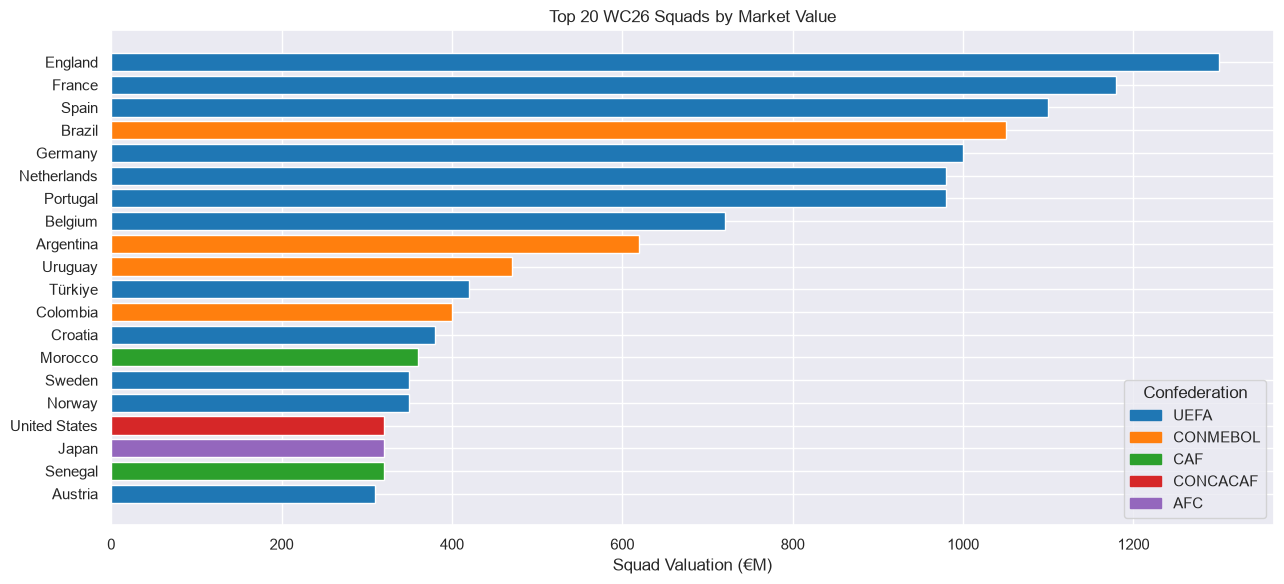

In [21]:
# Top 20 squads by market value
df = con.execute("""
    SELECT espn_name AS nation, confederation, squad_valuation_m_eur
    FROM nations
    WHERE squad_valuation_m_eur IS NOT NULL
    ORDER BY squad_valuation_m_eur DESC LIMIT 20
""").df()

palette = sns.color_palette('tab10', df['confederation'].nunique())
conf_colors = {c: palette[i] for i, c in enumerate(df['confederation'].unique())}
colors = df['confederation'].map(conf_colors)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(df['nation'], df['squad_valuation_m_eur'], color=colors)
ax.set_xlabel('Squad Valuation (€M)')
ax.set_title('Top 20 WC26 Squads by Market Value')
ax.invert_yaxis()
# confederation legend
from matplotlib.patches import Patch
legend_els = [Patch(color=v, label=k) for k, v in conf_colors.items()]
ax.legend(handles=legend_els, title='Confederation', loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
# Goals vs assists scatter — bubble = market value
df = con.execute("""
    SELECT
        e.name, n.espn_name AS nation, e.position,
        e.wc_goals, e.wc_assists,
        COALESCE(e.market_value_eur_tm, 0) / 1e6 AS mv_m
    FROM enrichment e
    JOIN nations n ON e.nation_id = n.nation_id
    WHERE e.wc_goals + e.wc_assists > 0
""").df()

fig = px.scatter(
    df, x='wc_goals', y='wc_assists',
    size='mv_m', size_max=40,
    color='position',
    hover_data=['name', 'nation', 'mv_m'],
    title='WC26 Goals vs Assists (bubble = market value)',
    labels={'wc_goals': 'Goals', 'wc_assists': 'Assists', 'position': 'Position'}
)
fig.show()

ValueError: zero-size array to reduction operation fmin which has no identity

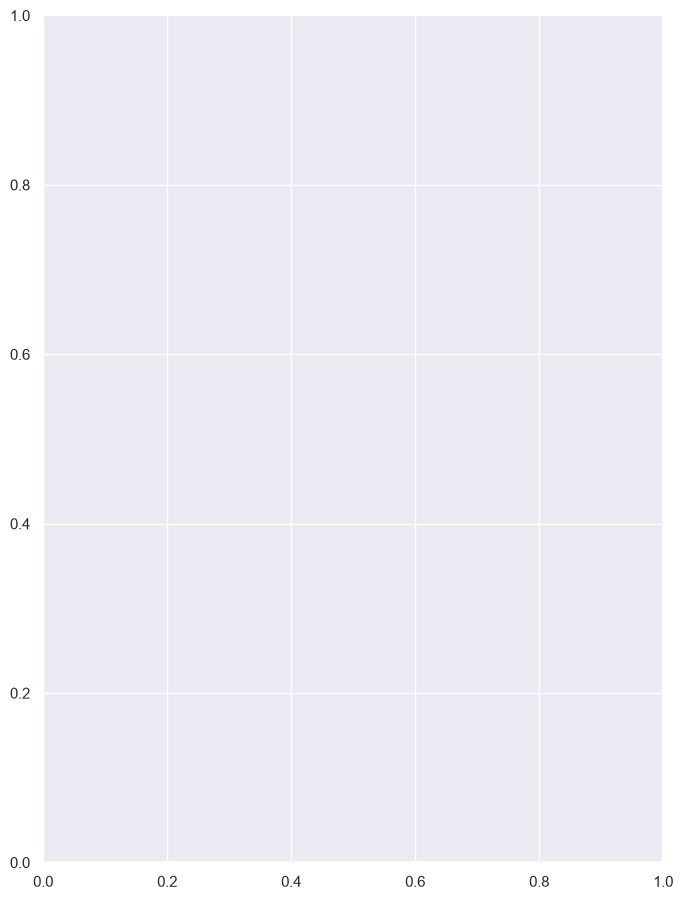

In [23]:
# Attacking vs Defensive powerrank — top 30 players
df = con.execute("""
    SELECT
        e.name,
        AVG(pr.attacking_score)  AS attack,
        AVG(pr.defensive_score)  AS defense,
        AVG(pr.creativity_score) AS creativity,
        COUNT(*) AS n_matches
    FROM powerrank pr
    JOIN enrichment e ON pr.fifa_player_id = e.fifa_player_id
    WHERE pr.player_kind = 'player'
    GROUP BY e.name
    HAVING n_matches >= 3
    ORDER BY attack DESC LIMIT 30
""").df().set_index('name')

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(
    df[['attack', 'defense', 'creativity']],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, ax=ax
)
ax.set_title('Avg PowerRank Scores — Top 30 Players (≥3 matches)')
plt.tight_layout()
plt.show()

In [ ]:
# Position breakdown across all squads
df = con.execute("""
    SELECT position, COUNT(*) AS count
    FROM players
    GROUP BY position ORDER BY count DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='position', y='count', ax=ax, palette='viridis')
ax.set_title('Player Count by Position')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Temperature distribution by stadium city
df = con.execute("""
    SELECT s.city, w.temperature_c
    FROM weather w
    JOIN matches m  ON w.fifa_match_id = m.fifa_match_id
    JOIN stadiums s ON m.stadium_id    = s.stadium_id
""").df()

order = df.groupby('city')['temperature_c'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x='city', y='temperature_c', order=order, ax=ax, palette='coolwarm')
ax.set_title('Match-Time Temperature by City')
ax.set_xlabel('')
ax.set_ylabel('°C')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Market value distribution by position (log scale)
df = con.execute("""
    SELECT position, market_value_eur_tm / 1e6 AS mv_m
    FROM enrichment
    WHERE market_value_eur_tm > 0
""").df()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='position', y='mv_m', ax=ax,
            order=['GK','DF','MF','FW'], palette='Set2')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:.0f}M'))
ax.set_title('Player Market Value Distribution by Position (log scale)')
ax.set_xlabel('')
ax.set_ylabel('Market Value')
plt.tight_layout()
plt.show()

In [ ]:
# Fantasy: price vs total points — best value picks
df = con.execute("""
    SELECT
        fp.known_name AS player, fp.position, fp.price, fp.total_points,
        fs.name AS squad,
        ROUND(fp.total_points * 1.0 / NULLIF(fp.price, 0), 2) AS pts_per_price
    FROM fantasy_players fp
    JOIN fantasy_squads fs ON fp.fantasy_squad_id = fs.fantasy_squad_id
    WHERE fp.total_points > 0 AND fp.price > 0
""").df()

fig = px.scatter(
    df, x='price', y='total_points',
    color='position',
    hover_data=['player', 'squad', 'pts_per_price'],
    title='Fantasy: Price vs Total Points',
    labels={'price': 'Fantasy Price', 'total_points': 'Total Points'}
)
fig.show()

In [ ]:
# Goals per confederation
df = con.execute("""
    SELECT n.confederation,
           SUM(e.wc_goals)   AS total_goals,
           SUM(e.wc_assists) AS total_assists,
           COUNT(DISTINCT n.nation_id) AS teams
    FROM enrichment e
    JOIN nations n ON e.nation_id = n.nation_id
    GROUP BY confederation
    ORDER BY total_goals DESC
""").df()

df_melted = df.melt(id_vars='confederation', value_vars=['total_goals','total_assists'],
                    var_name='stat', value_name='count')
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_melted, x='confederation', y='count', hue='stat', ax=ax)
ax.set_title('Goals & Assists by Confederation')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Market value trend for a single top player — change the name below
PLAYER_NAME = con.execute("""
    SELECT name FROM enrichment
    WHERE market_value_eur_tm = (SELECT MAX(market_value_eur_tm) FROM enrichment)
""").fetchone()[0]

player_id = con.execute(
    f"SELECT fifa_player_id FROM enrichment WHERE name = '{PLAYER_NAME}'"
).fetchone()[0]

df = con.execute(f"""
    SELECT date, value_eur / 1e6 AS value_m
    FROM market_value
    WHERE fifa_player_id = '{player_id}'
    ORDER BY date
""").df()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['date'], df['value_m'], marker='o', linewidth=2)
ax.fill_between(df['date'], df['value_m'], alpha=0.15)
ax.set_title(f'Market Value Over Time — {PLAYER_NAME}')
ax.set_ylabel('Value (€M)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Interactive map of stadiums (needs plotly)
df = con.execute("""
    SELECT s.name AS stadium, s.city, s.country, s.capacity,
           s.latitude, s.longitude, s.surface, s.roof_type,
           COUNT(m.match_number) AS matches_hosted
    FROM stadiums s
    LEFT JOIN matches m ON s.stadium_id = m.stadium_id
    GROUP BY 1,2,3,4,5,6,7,8
""").df()

fig = px.scatter_map(
    df, lat='latitude', lon='longitude',
    size='capacity', color='matches_hosted',
    hover_name='stadium',
    hover_data=['city', 'capacity', 'surface', 'roof_type', 'matches_hosted'],
    color_continuous_scale='Turbo',
    zoom=3, height=520,
    title='WC26 Stadiums'
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()

---
## 5. Advanced — Pivot, Rank, Window Functions

In [ ]:
# Rank players within each nation by market value
con.execute("""
    SELECT
        e.name, e.position, n.espn_name AS nation,
        e.market_value_eur_tm / 1e6 AS mv_m,
        RANK() OVER (PARTITION BY e.nation_id ORDER BY e.market_value_eur_tm DESC) AS rank_in_squad
    FROM enrichment e
    JOIN nations n ON e.nation_id = n.nation_id
    WHERE e.market_value_eur_tm IS NOT NULL
    QUALIFY rank_in_squad <= 3
    ORDER BY n.espn_name, rank_in_squad
""").df()

In [ ]:
# Fantasy value efficiency: points per million price
con.execute("""
    SELECT
        fp.known_name           AS player,
        fp.position,
        fs.name                 AS squad,
        fp.price,
        fp.total_points,
        ROUND(fp.total_points * 1.0 / fp.price, 3) AS pts_per_price_unit,
        RANK() OVER (PARTITION BY fp.position ORDER BY fp.total_points * 1.0 / fp.price DESC) AS value_rank
    FROM fantasy_players fp
    JOIN fantasy_squads fs ON fp.fantasy_squad_id = fs.fantasy_squad_id
    WHERE fp.price > 0 AND fp.total_points > 5
    QUALIFY value_rank <= 5
    ORDER BY fp.position, value_rank
""").df()

In [ ]:
# Cumulative goals by top 5 nations across match numbers
df_raw = con.execute("""
    SELECT
        m.match_number,
        n.espn_name AS nation,
        SUM(CASE WHEN m.home_nation_id = n.nation_id THEN m.home_score
                 WHEN m.away_nation_id = n.nation_id THEN m.away_score
                 ELSE 0 END) AS goals_in_match
    FROM matches m
    JOIN nations n ON n.nation_id IN (m.home_nation_id, m.away_nation_id)
    WHERE m.home_score IS NOT NULL
    GROUP BY 1, 2
""").df()

top_nations = (
    df_raw.groupby('nation')['goals_in_match'].sum()
    .nlargest(5).index.tolist()
)

df_top = df_raw[df_raw['nation'].isin(top_nations)].copy()
df_top = df_top.sort_values('match_number')
df_top['cumulative_goals'] = df_top.groupby('nation')['goals_in_match'].cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
for nation, grp in df_top.groupby('nation'):
    ax.plot(grp['match_number'], grp['cumulative_goals'], marker='o', label=nation)
ax.set_title('Cumulative Goals — Top 5 Nations')
ax.set_xlabel('Match Number')
ax.set_ylabel('Cumulative Goals')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Correlation matrix: squad value vs FIFA rank vs WC goals
df = con.execute("""
    SELECT
        n.fifa_rank,
        n.squad_valuation_m_eur,
        SUM(e.wc_goals)   AS total_goals,
        SUM(e.wc_assists) AS total_assists
    FROM nations n
    JOIN enrichment e ON n.nation_id = e.nation_id
    GROUP BY 1, 2
""").df().dropna()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation: FIFA Rank · Squad Value · Goals')
plt.tight_layout()
plt.show()